# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [433]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [434]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('Telco-Customer-Churn.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [435]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [436]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [437]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [438]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [439]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [440]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

TotalCharges    11
dtype: int64


<Axes: xlabel='Churn', ylabel='count'>

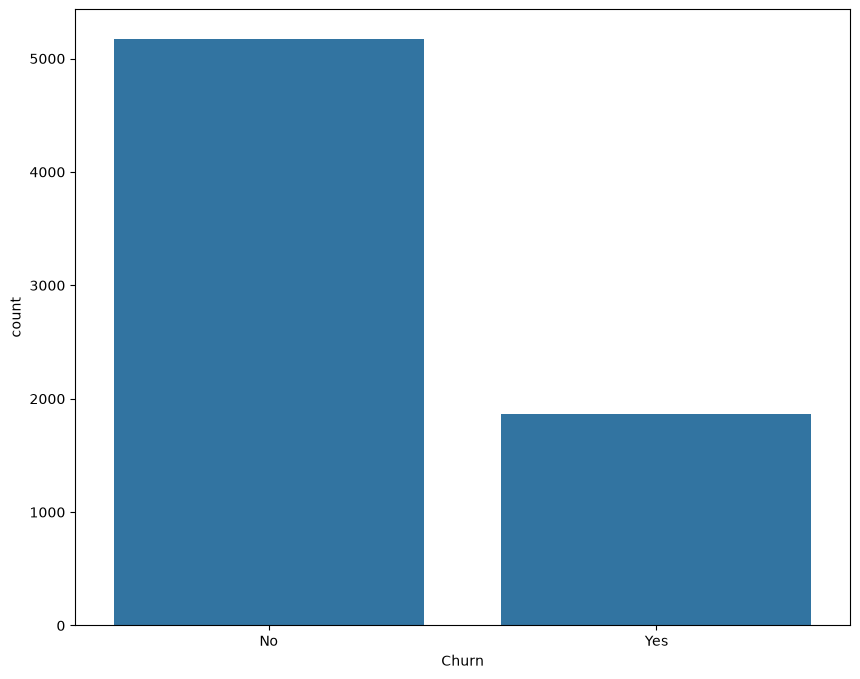

In [441]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    x='Churn'
)

Perbandingannya class nya jauh dataset ini imbalanced

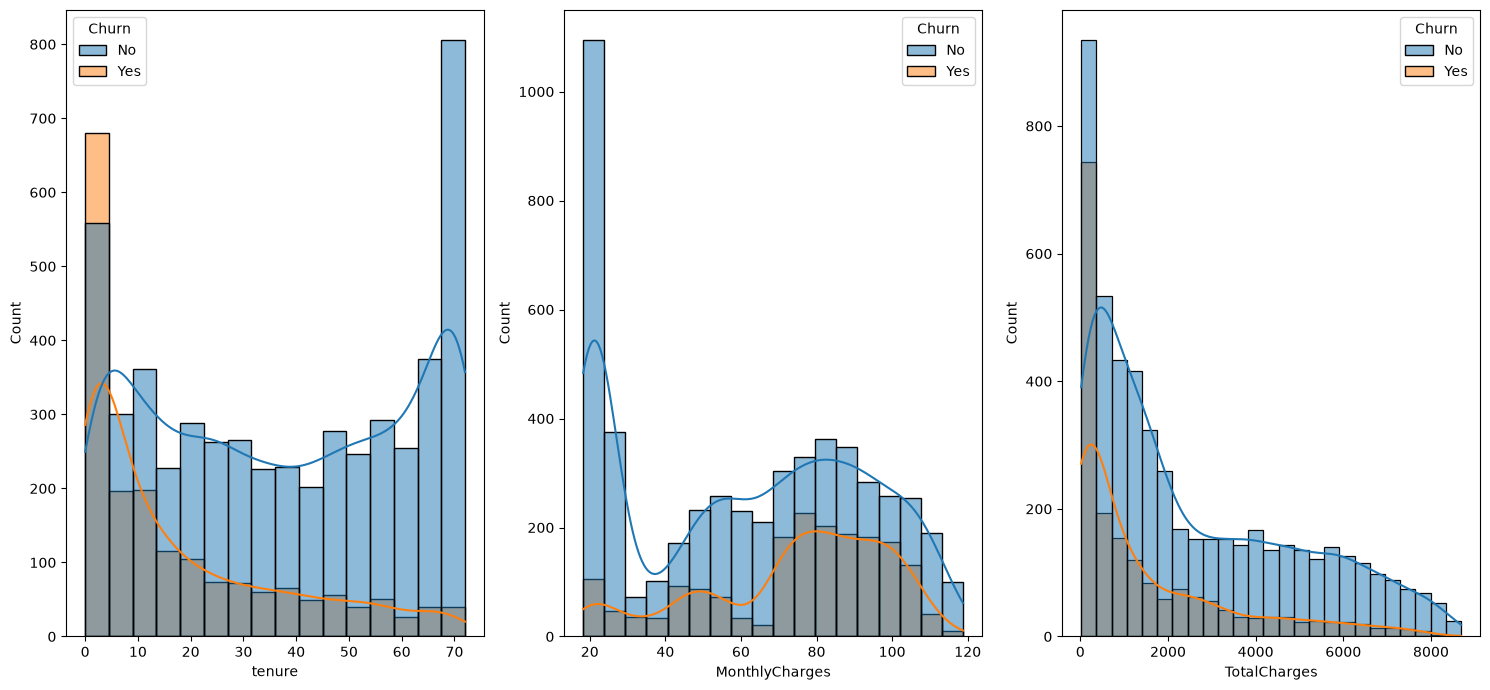

In [442]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="Churn",
        kde=True,
        ax=axes[i]
    )
    axes[i]

plt.tight_layout()
plt.show()

C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_6836\120584665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_6836\120584665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_6836\120584665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')


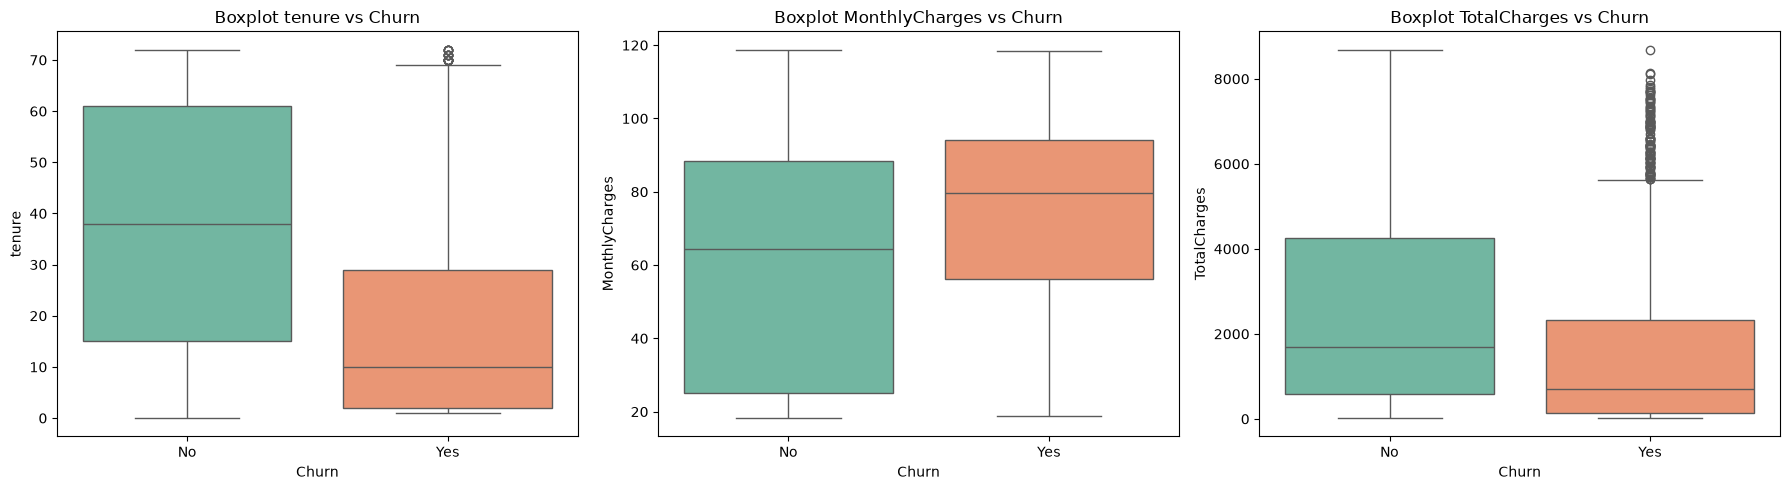

In [443]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot {col} vs Churn')

plt.tight_layout()
plt.show()


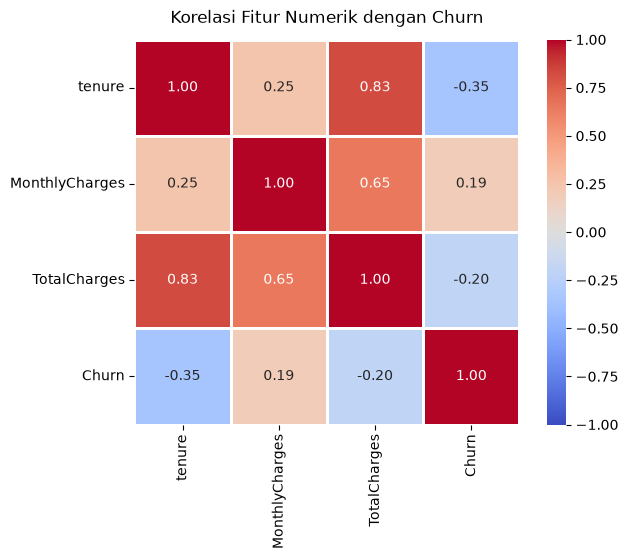

In [444]:
temp_df = df[num_cols].copy()
temp_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(7, 5))
sns.heatmap(
    temp_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    linewidths=1,
    square=True
)
plt.title('Korelasi Fitur Numerik dengan Churn', fontsize=12, pad=12)
plt.show()


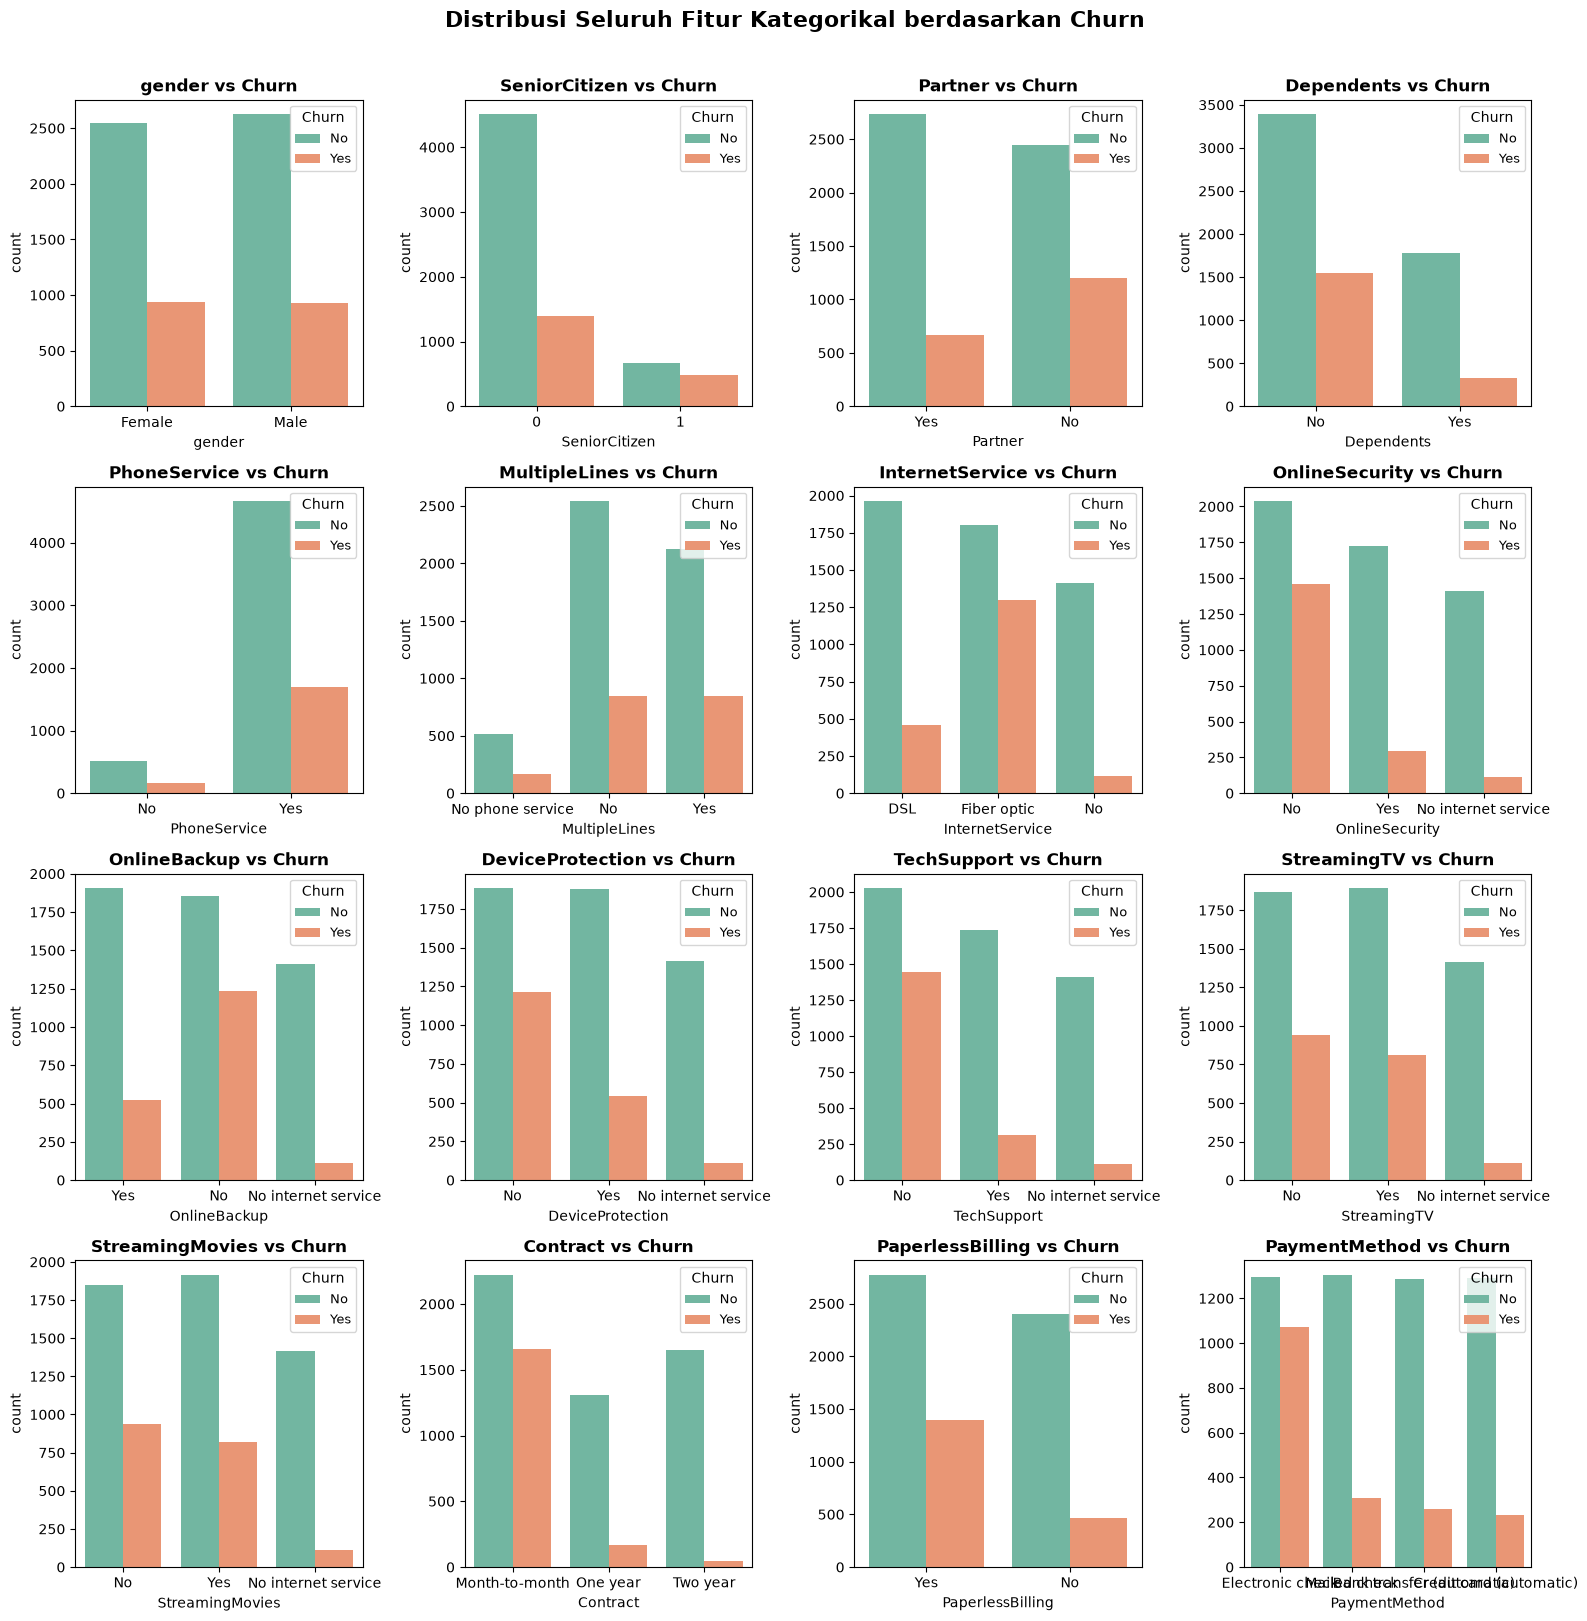

In [445]:
all_cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(all_cat_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue='Churn', 
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].legend(title='Churn', loc='upper right', fontsize=9)

plt.suptitle('Distribusi Seluruh Fitur Kategorikal berdasarkan Churn', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Fitur yang Hampir Tidak Berpengaruh (Distribusi 50:50 seimbang):

gender: Laki-laki dan perempuan memiliki rasio churn yang persis sama.

PhoneService: Pelanggan yang punya telepon atau tidak punya telepon churn rate-nya hampir sama.

Fitur yang Pengaruhnya Sangat Kuat:

Contract: Month-to-month mendominasi jumlah churn.

OnlineSecurity & TechSupport: Pelanggan yang statusnya "No" memiliki bar oranye (Churn) yang jauh lebih tinggi.

PaymentMethod: Pelanggan dengan metode "Electronic check" churn-nya paling tinggi dibanding 3 metode lainnya.

SeniorCitizen: Lansia (nilai 1) memiliki persentase churn yang lebih tinggi dibanding non-lansia.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [446]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Tangani missing value dengan menghapus baris yang memiliki nilai kosong pada TotalCharges
df = df.dropna().reset_index(drop=True)

# Verifikasi bahwa sudah tidak ada missing value yang tersisa
print("Jumlah total missing value setelah penanganan:", df.isnull().sum().sum())
print("Jumlah baris dataset sekarang:", df.shape[0])


Jumlah total missing value setelah penanganan: 0
Jumlah baris dataset sekarang: 7032


Drop baris TotalCharge yang ada NaN nya

In [447]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df = df.drop(columns=['customerID'])

X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [c for c in X.columns if c not in num_features]

print('Fitur numerik:', num_features)
print('Fitur kategorikal:', cat_features)
print(X.shape)

Fitur numerik: ['tenure', 'MonthlyCharges', 'TotalCharges']
Fitur kategorikal: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(7032, 19)


In [448]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Distribusi y_train:\n', y_train.value_counts(normalize=True))
print('Distribusi y_test:\n', y_test.value_counts(normalize=True))

X_train: (5625, 19) | X_test: (1407, 19)
Distribusi y_train:
 Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Distribusi y_test:
 Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [449]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

print('X_train_processed:', X_train_processed.shape)
print('X_test_processed:', X_test_processed.shape)
print('Contoh nama fitur hasil encoding:', preprocess.get_feature_names_out()[:8])

X_train_processed: (5625, 46)
X_test_processed: (1407, 46)
Contoh nama fitur hasil encoding: ['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__SeniorCitizen_0'
 'cat__SeniorCitizen_1' 'cat__Partner_No']


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [450]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
MLP_Relu = MLPClassifier(
   hidden_layer_sizes=(5,),
   activation='relu',
   solver='adam',
   max_iter=200,
   random_state=42,
)

MLP_Relu.fit(X_train_processed, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(5,)"
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [451]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
# Prediksi nilai target untuk data uji
y_pred = MLP_Relu.predict(X_test_processed)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No-Churn','Churn']))

Accuracy : 0.7974
Precision: 0.6459
Recall   : 0.5267
F1-Score : 0.5803

              precision    recall  f1-score   support

    No-Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [452]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

models = {}
for act in ['relu', 'tanh', 'logistic']:
    mlp = MLPClassifier(
        hidden_layer_sizes=(5,),
        activation=act,
        solver='adam',
        max_iter=300, 
        random_state=42
        )

    mlp.fit(X_train_processed, y_train)
    models[act] = mlp
    print(act, "selesai")
    
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

relu selesai
tanh selesai
logistic selesai


In [453]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
rows = []
for act, m in models.items():
    y_p = m.predict(X_test_processed)
    rows.append({
        'activation': act,
        'accuracy': accuracy_score(y_test, y_p),
        'precision': precision_score(y_test, y_p),
        'recall': recall_score(y_test, y_p),
        'f1': f1_score(y_test, y_p)
    })

df_act = pd.DataFrame(rows)
print(df_act.round(4))

  activation  accuracy  precision  recall      f1
0       relu    0.7974     0.6459  0.5267  0.5803
1       tanh    0.7946     0.6451  0.5053  0.5667
2   logistic    0.7974     0.6431  0.5348  0.5839


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [454]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
arch_list = [(2,), (5,), (10,), (50,), (100, 50)]
arch_models = {}
for h in arch_list:
    mlp = MLPClassifier(hidden_layer_sizes=h, activation='relu', solver='adam', max_iter=300, random_state=42)
    mlp.fit(X_train_processed, y_train)
    arch_models[str(h)] = mlp
print("selesai:", list(arch_models.keys()))


c:\Users\LAPTOPKU\KULIAH\KULIAH SMT 3\ML-Praktik\ML-RKA-25-El\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


selesai: ['(2,)', '(5,)', '(10,)', '(50,)', '(100, 50)']


c:\Users\LAPTOPKU\KULIAH\KULIAH SMT 3\ML-Praktik\ML-RKA-25-El\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [455]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = []
test_acc = []
for k, m in arch_models.items():
    train_acc.append(m.score(X_train_processed, y_train))
    test_acc.append(m.score(X_test_processed, y_test))
for k, tr, te in zip(arch_models.keys(), train_acc, test_acc):
    print(f"{k:10s} train={tr:.4f} test={te:.4f} gap={tr-te:.4f}")


(2,)       train=0.8043 test=0.8024 gap=0.0019
(5,)       train=0.8092 test=0.7974 gap=0.0118
(10,)      train=0.8149 test=0.7903 gap=0.0246
(50,)      train=0.8455 test=0.7740 gap=0.0715
(100, 50)  train=0.9452 test=0.7534 gap=0.1919


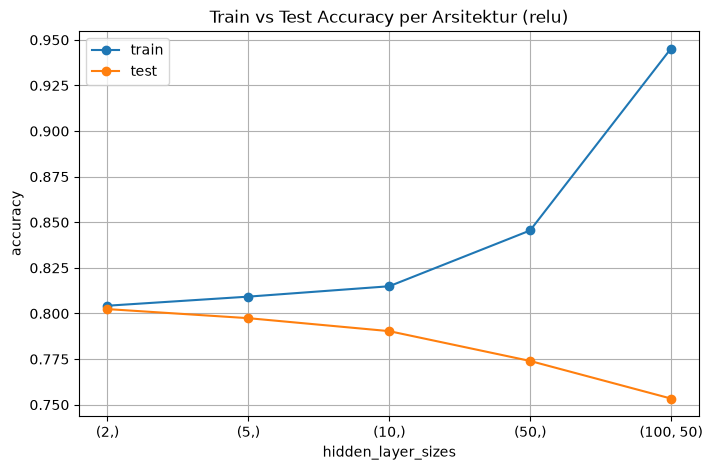

In [456]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
x_labels = list(arch_models.keys())
plt.figure(figsize=(8, 5))
plt.plot(x_labels, train_acc, marker='o', label='train')
plt.plot(x_labels, test_acc, marker='o', label='test')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('accuracy')
plt.title('Train vs Test Accuracy per Arsitektur (relu)')
plt.legend()
plt.grid(True)
plt.show()


# 4. Evaluasi Model

In [457]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
best_act = models['relu']
best_arch = arch_models['(2,)']
rows = []
for name, m in [('relu-(1,) [3.2]', best_act), ('relu-(2,) [3.3]', best_arch)]:
    yp = m.predict(X_test_processed)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall': recall_score(y_test, yp),
        'f1': f1_score(y_test, yp)
    })
import pandas as pd
df_eval = pd.DataFrame(rows)
print(df_eval.round(4))


             model  accuracy  precision  recall      f1
0  relu-(1,) [3.2]    0.7974     0.6459  0.5267  0.5803
1  relu-(2,) [3.3]    0.8024     0.6463  0.5668  0.6040


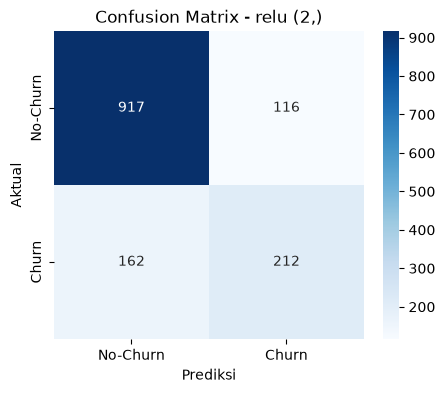

In [458]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
from sklearn.metrics import confusion_matrix
best_model = arch_models['(2,)']
y_best = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, y_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No-Churn','Churn'], yticklabels=['No-Churn','Churn'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - relu (2,)')
plt.show()


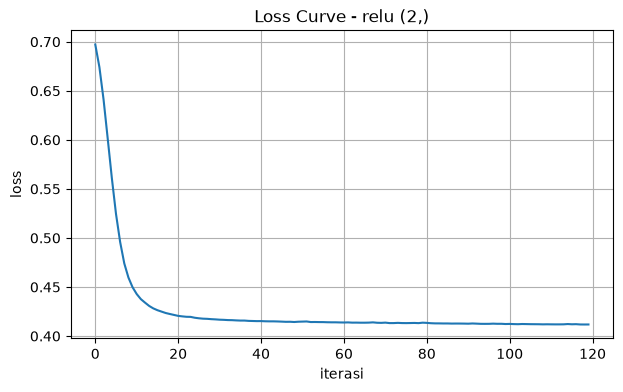

n_iter: 120 | loss akhir: 0.4118


In [459]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(7, 4))
plt.plot(best_model.loss_curve_)
plt.xlabel('iterasi')
plt.ylabel('loss')
plt.title('Loss Curve - relu (2,)')
plt.grid(True)
plt.show()
print("n_iter:", best_model.n_iter_, "| loss akhir:", round(best_model.loss_, 4))


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Fungsi aktivasi bedanya tidak signifikan (acc 0.783-0.800, f1 0.603-0.615). relu unggul accuracy/precision, logistic unggul recall (0.6417) karena output sigmoid agresif menebak Churn, tanh paling seimbang (f1 0.6152) karena zero-centered. relu dipilih lanjut karena standar hidden layer, tidak saturasi, dan training stabil.

Overfitting mulai terlihat di (50,): train terus naik 0.80->0.84->0.94 tapi test turun 0.802->0.774->0.753. Gap train-test melebar dari 0.002 ke 0.19. Di grafik, kurva train naik tajam sementara test stagnan/menurun setelah (10,). Model terbaik (2,) karena gap terkecil dan test tertinggi.

Loss curve (2,) sudah konvergen (datar di 0.41, berhenti di iter 120 < 300). Jika loss masih turun tajam saat max_iter tercapai (seperti warning di percobaan (1,) 200 iter), naikkan max_iter ke 300-500, cek n_iter_, atau turunkan learning rate / tambah alpha.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

ANN terbaik adalah MLP relu (2,) dengan acc 0.8024, f1 0.604. Arsitektur kecil justru generalisasi paling baik untuk data Telco ini; memperbesar ke (100,50) hanya menghafal train (0.945) dan test drop ke 0.753. Saran: coba solver='sgd', tuning alpha (L2), GridSearchCV untuk hidden_layer_sizes+alpha, atasi imbalance dengan class_weight/SMOTE, dan bandingkan dengan SVM/Random Forest.